<a href="https://colab.research.google.com/github/lricci03/Hands-on-ML/blob/main/c10/c10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Working on Chapter 10

In [ ]:
import torch

Set up GPU

In [ ]:
if torch.cuda.is_available():
  device = 'cuda'
elif torch.backends.mps.is_available():
  device = 'mps'
else:
  device = 'cpu'

In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

housing = fetch_california_housing()
X_train_full, X_test, y_train_full, y_test = train_test_split(
    housing.data, housing.target, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, random_state=42)

Conver the data into tensors

In [ ]:
X_train = torch.FloatTensor(X_train)
X_valid = torch.FloatTensor(X_valid)
X_test = torch.FloatTensor(X_test)
y_train = torch.FloatTensor(y_train).reshape(-1,1)
y_valid = torch.FloatTensor(y_valid).reshape(-1,1)
y_test = torch.FloatTensor(y_test).reshape(-1,1)

Scale the X data - could use StandardScaler but do it with tensor operations

In [ ]:
means = X_train.mean(dim=0,keepdims=True) # dim=0 to take the mean along columns
stds = X_train.std(dim=0,keepdims=True)
X_train = (X_train - means)/stds
X_valid = (X_valid - means)/stds
X_test = (X_test - means)/stds

In [ ]:
import torch.nn as nn

Create a model with 2 hidden layers (with 50 and 40 neurons) and one output layer with a single neuron

In [ ]:
torch.manual_seed(42)
n_features = X_train.shape[1]
model = nn.Sequential(
    nn.Linear(n_features, 50),
    nn.ReLU(),
    nn.Linear(50,40),
    nn.ReLU(),
    nn.Linear(40,1)
)
model = model.to(device) # move the model to GPU, if available
device # output is CPU

'cpu'

Define a function to train the model with mini-batch gradient descent

Turn the dataset tensors into datasets objects with the required API

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

In [ ]:
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True) # shuffle the dataset during training

valid_dataset = TensorDataset(X_valid, y_valid)
valid_loader = DataLoader(valid_dataset, batch_size=32) # no need to shuffle

Create a train() function to implement mini-batch GD, evaluating the train and validation sets for each epoch

In [ ]:
!pip install -q torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 21.2 MB/s eta 0:00:00


In [ ]:
def train(model, optimizer, criterion, train_loader, valid_loader, n_epochs):
  train_losses = [] # store train & validation losses in a list to plot them
  valid_losses = []
  for epoch in range(n_epochs):
    model.train()
    total_loss = 0.

    for X_batch, y_batch in train_loader:
      X_batch, y_batch = X_batch.to(device), y_batch.to(device)
      y_pred = model(X_batch)
      loss = criterion(y_pred, y_batch)
      total_loss += loss.item()
      loss.backward() # propagates the gradients through the computation graph
      optimizer.step() # changes the weights and the biases
      optimizer.zero_grad() # set the gradient back to zero

    mean_loss = total_loss / len(train_loader)
    train_losses.append(mean_loss)
    print(f'Epoch {epoch + 1}/{n_epochs}, Train set Loss (MSE): {mean_loss:.4f}')

    with torch.no_grad():
      model.eval()
      total_val_loss = 0.
      for X_batch_val, y_batch_val in valid_loader:
        X_batch_val, y_batch_val = X_batch_val.to(device), y_batch_val.to(device)
        y_pred_val = model(X_batch_val)
        val_loss = criterion(y_pred_val, y_batch_val)
        total_val_loss += val_loss.item()
      mean_val_loss = total_val_loss / len(valid_loader)
      valid_losses.append(mean_val_loss)
      print(f'Epoch {epoch + 1}/{n_epochs}, Validation set MSE: {mean_val_loss:.4f}')
  return train_losses, valid_losses

In [ ]:
learning_rate = 0.02
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
mse = nn.MSELoss()

In [ ]:
train_losses, valid_losses = train(model,optimizer, mse, train_loader, valid_loader, 50)

Epoch 1/50, Train set Loss (MSE): 0.5900
Epoch 1/50, Validation set MSE: 0.6636
Epoch 2/50, Train set Loss (MSE): 0.4048
Epoch 2/50, Validation set MSE: 1.0683
Epoch 3/50, Train set Loss (MSE): 0.3859
Epoch 3/50, Validation set MSE: 0.3706
Epoch 4/50, Train set Loss (MSE): 0.3643
Epoch 4/50, Validation set MSE: 0.3942
Epoch 5/50, Train set Loss (MSE): 0.3524
Epoch 5/50, Validation set MSE: 0.3610
Epoch 6/50, Train set Loss (MSE): 0.3501
Epoch 6/50, Validation set MSE: 0.3239
Epoch 7/50, Train set Loss (MSE): 0.3435
Epoch 7/50, Validation set MSE: 0.3795
Epoch 8/50, Train set Loss (MSE): 0.3419
Epoch 8/50, Validation set MSE: 0.3545
Epoch 9/50, Train set Loss (MSE): 0.3389
Epoch 9/50, Validation set MSE: 0.3833
Epoch 10/50, Train set Loss (MSE): 0.3340
Epoch 10/50, Validation set MSE: 0.3234
Epoch 11/50, Train set Loss (MSE): 0.3303
Epoch 11/50, Validation set MSE: 0.3119
Epoch 12/50, Train set Loss (MSE): 0.3270
Epoch 12/50, Validation set MSE: 0.3644
Epoch 13/50, Train set Loss (MSE):

Plot the validation and train losses as a function of epochs

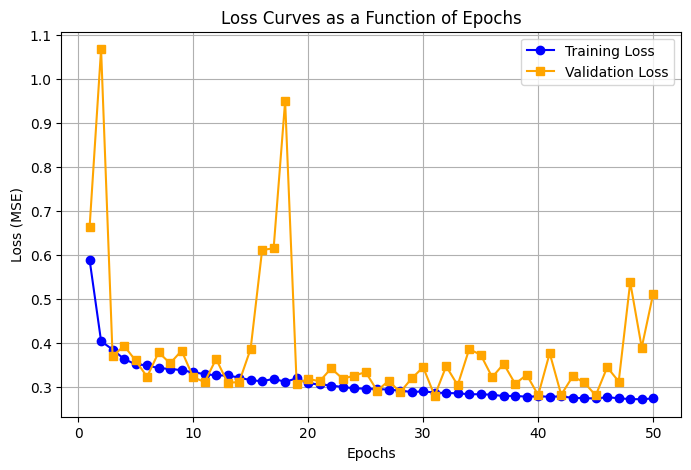

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

# Plot the lines
plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, label='Training Loss', color='blue', marker='o')
plt.plot(epochs, valid_losses, label='Validation Loss', color='orange', marker='s')

# Format the graph
plt.title('Loss Curves as a Function of Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.grid(True)
plt.legend()

plt.show()


## Define the same function using TorchMetrics (installed above)

In [ ]:
import torchmetrics

In [ ]:
def train2(model, optimizer, train_loader, valid_loader, n_epochs):
  train_rmse = torchmetrics.MeanSquaredError(squared=False).to(device) # data is to device, so should be the metrics
  valid_rmse = torchmetrics.MeanSquaredError(squared=False).to(device)
  for epoch in range(n_epochs):
    model.train()
    train_rmse.reset()
    criterion = nn.MSELoss()

    for X_batch, y_batch in train_loader:
      X_batch, y_batch = X_batch.to(device), y_batch.to(device)
      y_pred = model(X_batch)
      train_rmse(y_pred, y_batch) # 'partially' update L2 norm (RMSE)
      loss = criterion(y_pred, y_batch) # mean squared error (squared L2 norm)
      loss.backward() # propagates the gradients through the computation graph
      optimizer.step() # changes the weights and the biases
      optimizer.zero_grad() # set the gradient back to zero

    epoch_rmse = train_rmse.compute()
    print(f'Epoch {epoch + 1}/{n_epochs}, Train RMSE: {epoch_rmse:.4f}')

    with torch.no_grad():
      model.eval()
      valid_rmse.reset()
      for X_batch_val, y_batch_val in valid_loader:
        X_batch_val, y_batch_val = X_batch_val.to(device), y_batch_val.to(device)
        y_pred_val = model(X_batch_val)
        valid_rmse.update(y_pred_val, y_batch_val)

      epoch_valid_rmse = valid_rmse.compute()
      print(f'Epoch {epoch + 1}/{n_epochs}, Validation RMSE: {epoch_valid_rmse:.4f}')

Same model as before, instantiate it again to re-inizialize the weights

In [ ]:
torch.manual_seed(42)
n_features = X_train.shape[1]
model = nn.Sequential(
    nn.Linear(n_features, 50),
    nn.ReLU(),
    nn.Linear(50,40),
    nn.ReLU(),
    nn.Linear(40,1)
)
model = model.to(device) # move the model to GPU, if available
device # output is CPU

'cpu'

Set up learning rate and optimizer - it is important to do this AFTER we initialize the model

In [ ]:
learning_rate = 0.02
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [ ]:
train2(model,optimizer,train_loader,valid_loader,n_epochs=10)

Epoch 1/10, Train RMSE: 0.7682
Epoch 1/10, Validation RMSE: 0.8148
Epoch 2/10, Train RMSE: 0.6362
Epoch 2/10, Validation RMSE: 1.0338
Epoch 3/10, Train RMSE: 0.6212
Epoch 3/10, Validation RMSE: 0.6089
Epoch 4/10, Train RMSE: 0.6036
Epoch 4/10, Validation RMSE: 0.6280
Epoch 5/10, Train RMSE: 0.5936
Epoch 5/10, Validation RMSE: 0.6009
Epoch 6/10, Train RMSE: 0.5916
Epoch 6/10, Validation RMSE: 0.5692
Epoch 7/10, Train RMSE: 0.5858
Epoch 7/10, Validation RMSE: 0.6161
Epoch 8/10, Train RMSE: 0.5846
Epoch 8/10, Validation RMSE: 0.5955
Epoch 9/10, Train RMSE: 0.5822
Epoch 9/10, Validation RMSE: 0.6192
Epoch 10/10, Train RMSE: 0.5780
Epoch 10/10, Validation RMSE: 0.5687


Instead of just training, we want to save the error of both train and validation for each epoch to plot them

In [ ]:
import matplotlib.pyplot as plt

def train_and_plot(model, optimizer, train_loader, valid_loader, n_epochs):
  train_rmse = torchmetrics.MeanSquaredError(squared=False).to(device) # data is to device, so should be the metrics
  valid_rmse = torchmetrics.MeanSquaredError(squared=False).to(device)
  rmse = {'train_rmse': [], 'valid_rmse': []}
  for epoch in range(n_epochs):
    model.train()
    train_rmse.reset()
    criterion = nn.MSELoss()

    for X_batch, y_batch in train_loader:
      X_batch, y_batch = X_batch.to(device), y_batch.to(device)
      y_pred = model(X_batch)
      train_rmse(y_pred, y_batch) # compute L2 norm (RMSE)
      loss = criterion(y_pred, y_batch) # mean squared error (squared L2 norm)
      loss.backward() # propagates the gradients through the computation graph
      optimizer.step() # changes the weights and the biases
      optimizer.zero_grad() # set the gradient back to zero

    epoch_rmse = train_rmse.compute()
    rmse['train_rmse'].append(epoch_rmse)

    with torch.no_grad():
      model.eval()
      valid_rmse.reset()
      for X_batch_val, y_batch_val in valid_loader:
        X_batch_val, y_batch_val = X_batch_val.to(device), y_batch_val.to(device)
        y_pred_val = model(X_batch_val)
        valid_rmse.update(y_pred_val, y_batch_val)

      epoch_valid_rmse = valid_rmse.compute()
      rmse['valid_rmse'].append(epoch_valid_rmse)
    #print(f'Epoch {epoch + 1}/{n_epochs}, Train RMSE: {epoch_rmse:.4f}, Validation RMSE: {epoch_valid_rmse:.4f}')

  # plot the graph

  epochs = range(1, len(rmse['train_rmse']) + 1)

  # Plot the lines
  plt.figure(figsize=(8, 5))
  plt.plot(epochs, rmse['train_rmse'], label='Training Loss', color='blue', marker='o')
  plt.plot(epochs, rmse['valid_rmse'], label='Validation Loss', color='orange', marker='s')

  # Format the graph
  plt.title('Loss Curves as a Function of Epochs')
  plt.xlabel('Epochs')
  plt.ylabel('Loss (RMSE)')
  plt.grid(True)
  plt.legend()

  plt.show()


  return rmse['train_rmse'], rmse['valid_rmse']

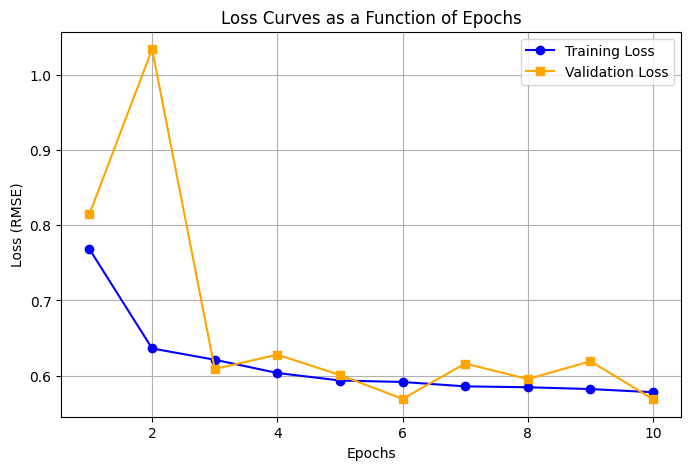

[tensor(0.7682), tensor(0.6362), tensor(0.6212), tensor(0.6036), tensor(0.5936), tensor(0.5916), tensor(0.5858), tensor(0.5846), tensor(0.5822), tensor(0.5780)]
[tensor(0.8148), tensor(1.0338), tensor(0.6089), tensor(0.6280), tensor(0.6009), tensor(0.5692), tensor(0.6161), tensor(0.5955), tensor(0.6192), tensor(0.5687)]


In [ ]:
train_rmse, valid_rmse = train_and_plot(model,optimizer,train_loader,valid_loader,n_epochs=10)
print(train_rmse)
print(valid_rmse)

In [ ]:
train2(model,optimizer,train_loader,valid_loader,n_epochs=10)

Epoch 1/10, Train RMSE: 0.5748
Epoch 1/10, Validation RMSE: 0.5585
Epoch 2/10, Train RMSE: 0.5719
Epoch 2/10, Validation RMSE: 0.6037
Epoch 3/10, Train RMSE: 0.5719
Epoch 3/10, Validation RMSE: 0.5574
Epoch 4/10, Train RMSE: 0.5676
Epoch 4/10, Validation RMSE: 0.5584
Epoch 5/10, Train RMSE: 0.5624
Epoch 5/10, Validation RMSE: 0.6224
Epoch 6/10, Train RMSE: 0.5601
Epoch 6/10, Validation RMSE: 0.7824
Epoch 7/10, Train RMSE: 0.5651
Epoch 7/10, Validation RMSE: 0.7850
Epoch 8/10, Train RMSE: 0.5590
Epoch 8/10, Validation RMSE: 0.9751
Epoch 9/10, Train RMSE: 0.5662
Epoch 9/10, Validation RMSE: 0.5552
Epoch 10/10, Train RMSE: 0.5561
Epoch 10/10, Validation RMSE: 0.5651
